# Неделя 1. Данные ADL Piano MIDI, EDA и REMI-токенизатор

<a href="https://colab.research.google.com/github/GumiTrb/ai-music-gen/blob/main/notebooks/week1_data_tokenizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Что здесь:
1. словарь токенов и REMI-токенизатор MIDI ↔ токены с префиксом условий (жанр, темп, длина) + тесты;
2. загрузка ADL Piano MIDI и разбор всех ~11 000 файлов;
3. анализ данных: жанры, фильтрация, длины, темпы, тональности, статистика токенов;
4. пример MIDI → токены → MIDI.

Всё, что нужно сохранить (код токенизатора, таблица пьес, словарь, MIDI-примеры), пишется в папку
`MyDrive/ai-music-gen/` на Google Диске — следующие недели берут это оттуда.
Ноутбук запускается целиком: *Среда выполнения → Выполнить все* (GPU не нужен, ~3–5 минут).

In [1]:
import os, sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip -q install miditoolkit
    from google.colab import drive
    drive.mount('/content/drive')
    WORK = Path('/content/drive/MyDrive/ai-music-gen')
else:
    WORK = Path('ai-music-gen-work').resolve()  # локальный запуск
CODE = WORK / 'code'       # vocab.py, remi.py, adl.py — импортируются на следующих неделях
DATA = WORK / 'data'       # архив датасета и результаты разбора
SAMPLES = WORK / 'samples' / 'week_1'
for d in (CODE, DATA, SAMPLES):
    d.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(CODE))
os.chdir(CODE)  # %%writefile пишет файлы сюда
print('рабочая папка:', WORK)

рабочая папка: ai-music-gen-work


## Настройки данных

Группировка жанров выбрана по EDA ниже: мелкие жанры ADL объединены в 7 крупных классов + `unknown`
(папка Unknown датасета, жанр не размечен).

In [2]:
CONFIG = dict(
    dataset_url='https://raw.githubusercontent.com/lucasnfe/adl-piano-midi/master/midi/adl-piano-midi.zip',
    genre_map={
        'Classical': 'classical', 'Rock': 'rock',
        'Pop': 'pop', 'Rap': 'pop', 'Electronic': 'pop', 'Reggae': 'pop', 'Children': 'pop',
        'Jazz': 'jazz', 'Blues': 'jazz', 'Soul': 'jazz',
        'Soundtracks': 'soundtrack', 'Ambient': 'soundtrack',
        'World': 'latin_world', 'Latin': 'latin_world',
        'Country': 'country_folk', 'Folk': 'country_folk', 'Religious': 'country_folk',
        'Unknown': 'unknown',
    },
    genres=['classical', 'rock', 'pop', 'jazz', 'soundtrack', 'latin_world', 'country_folk', 'unknown'],
    filters=dict(
        only_four_four=True,  # сетка REMI рассчитана на 4/4; файлы без размера считаем 4/4
        min_bars=8, min_notes=64,
        max_bars=400,         # отсекаем аномально длинные файлы
        min_bpm=30, max_bpm=260,
    ),
)

## 1. Словарь токенов

| тип | кол-во | смысл |
|---|---|---|
| `BAR` | 1 | начало такта |
| `POSITION` | 16 | позиция в такте (шаг 1/16) |
| `PITCH` | 88 | высота (клавиши фортепиано 21–108) |
| `DURATION` | 32 | длительность, 1–32 шестнадцатых |
| `VELOCITY` | 16 | громкость (velocity // 8) |
| `TEMPO` | 16 | бин темпа (48–208 BPM, ближайший в лог-шкале) |
| `LENGTH` | 10 | бин длины (8–256 тактов) |
| `GENRE` | 8 | жанровый класс |
| служебные | 3 | `PAD`, `BOS`, `EOS` |

```
BOS GENRE_jazz TEMPO_88 LENGTH_64 | BAR POSITION_0 PITCH_55 DURATION_15 VELOCITY_8 PITCH_58 ... BAR ... EOS
└──────── условия (префикс) ─────┘ └─────────────────────── тело пьесы ───────────────────────────┘
```

In [3]:
%%writefile vocab.py
"""Словарь REMI-токенов с управляющими токенами (жанр, темп, длина).

Порядок блоков в словаре выбран так, чтобы id «музыкальных» токенов не зависели
от списка жанров: условия (TEMPO, LENGTH, GENRE) лежат в конце. Поэтому один раз
токенизированный датасет можно использовать с разной группировкой жанров.

Последовательность выглядит так:
    BOS GENRE_g TEMPO_t LENGTH_l  BAR [POSITION_i] PITCH_p DURATION_d VELOCITY_v ... BAR ... EOS
"""

import json
import math
from dataclasses import dataclass, field
from pathlib import Path

PAD, BOS, EOS, BAR = 0, 1, 2, 3
SPECIAL_TOKENS = ["PAD", "BOS", "EOS", "BAR"]

N_POSITIONS = 16  # шаг 1/16 такта 4/4
PITCH_MIN, PITCH_MAX = 21, 108  # 88 клавиш фортепиано
N_DURATIONS = 32  # 1..32 шестнадцатых (до двух тактов)
N_VELOCITIES = 16  # velocity // 8

# Центры бинов темпа (BPM). Ближайший бин ищется в лог-шкале.
TEMPO_BINS = [48, 56, 64, 72, 80, 88, 96, 104, 112, 120, 128, 140, 152, 168, 184, 208]
# Центры бинов длины (в тактах).
LENGTH_BINS = [8, 16, 24, 32, 48, 64, 96, 128, 192, 256]

DEFAULT_GENRES = [
    "classical", "rock", "pop", "jazz", "soundtrack", "latin_world", "country_folk", "unknown",
]
UNKNOWN_GENRE = "unknown"
PREFIX_LEN = 4  # BOS, GENRE, TEMPO, LENGTH


def _nearest_log(value: float, centers: list[int]) -> int:
    value = max(float(value), 1e-6)
    return min(range(len(centers)), key=lambda i: abs(math.log(value) - math.log(centers[i])))


@dataclass
class Vocab:
    genres: list[str] = field(default_factory=lambda: list(DEFAULT_GENRES))

    def __post_init__(self):
        if UNKNOWN_GENRE not in self.genres:
            self.genres = list(self.genres) + [UNKNOWN_GENRE]
        names = list(SPECIAL_TOKENS)
        self.ranges: dict[str, tuple[int, int]] = {}

        def add(kind: str, items):
            start = len(names)
            names.extend(f"{kind}_{x}" for x in items)
            self.ranges[kind] = (start, len(names))

        add("POSITION", range(N_POSITIONS))
        add("PITCH", range(PITCH_MIN, PITCH_MAX + 1))
        add("DURATION", range(1, N_DURATIONS + 1))
        add("VELOCITY", range(N_VELOCITIES))
        add("TEMPO", TEMPO_BINS)
        add("LENGTH", LENGTH_BINS)
        add("GENRE", self.genres)
        self.names = names
        self.index = {n: i for i, n in enumerate(names)}

    # ---- размеры и типы -------------------------------------------------
    def __len__(self) -> int:
        return len(self.names)

    @property
    def n_body(self) -> int:
        """Число токенов, которые могут встречаться в теле пьесы (без условий)."""
        return self.ranges["VELOCITY"][1]

    def kind(self, tok: int) -> str:
        if tok < len(SPECIAL_TOKENS):
            return SPECIAL_TOKENS[tok]
        for k, (a, b) in self.ranges.items():
            if a <= tok < b:
                return k
        raise ValueError(f"unknown token id {tok}")

    def is_kind(self, tok: int, kind: str) -> bool:
        a, b = self.ranges[kind]
        return a <= tok < b

    def value(self, tok: int) -> int:
        """Индекс внутри своего блока (для PITCH возвращает MIDI-высоту)."""
        k = self.kind(tok)
        a, _ = self.ranges[k]
        if k == "PITCH":
            return tok - a + PITCH_MIN
        if k == "DURATION":
            return tok - a + 1
        return tok - a

    # ---- конструкторы токенов -------------------------------------------
    def position(self, i: int) -> int:
        return self.ranges["POSITION"][0] + i

    def pitch(self, p: int) -> int:
        return self.ranges["PITCH"][0] + p - PITCH_MIN

    def duration(self, d: int) -> int:
        return self.ranges["DURATION"][0] + min(max(d, 1), N_DURATIONS) - 1

    def velocity(self, v: int) -> int:
        return self.ranges["VELOCITY"][0] + min(max(v, 0), 127) // 8

    def tempo_bin(self, bpm: float) -> int:
        return _nearest_log(bpm, TEMPO_BINS)

    def tempo(self, bpm: float) -> int:
        return self.ranges["TEMPO"][0] + self.tempo_bin(bpm)

    def length_bin(self, n_bars: int) -> int:
        return _nearest_log(n_bars, LENGTH_BINS)

    def length(self, n_bars: int) -> int:
        return self.ranges["LENGTH"][0] + self.length_bin(n_bars)

    def genre(self, g: str) -> int:
        g = g if g in self.genres else UNKNOWN_GENRE
        return self.ranges["GENRE"][0] + self.genres.index(g)

    def prefix(self, genre: str, bpm: float, n_bars: int) -> list[int]:
        return [BOS, self.genre(genre), self.tempo(bpm), self.length(n_bars)]

    def decode_prefix(self, tokens) -> dict:
        out = {}
        for t in tokens[:PREFIX_LEN]:
            t = int(t)
            if t >= self.n_body:
                k = self.kind(t)
                v = self.value(t)
                if k == "TEMPO":
                    out["bpm"] = TEMPO_BINS[v]
                elif k == "LENGTH":
                    out["n_bars"] = LENGTH_BINS[v]
                elif k == "GENRE":
                    out["genre"] = self.genres[v]
        return out

    def to_str(self, tokens) -> list[str]:
        return [self.names[int(t)] for t in tokens]

    # ---- сохранение -------------------------------------------------------
    def save(self, path: str | Path) -> None:
        Path(path).write_text(json.dumps({"genres": self.genres, "names": self.names}, indent=1), encoding="utf-8")

    @classmethod
    def load(cls, path: str | Path) -> "Vocab":
        data = json.loads(Path(path).read_text(encoding="utf-8"))
        v = cls(genres=data["genres"])
        assert v.names == data["names"], "vocab.json не совпадает с текущим кодом словаря"
        return v

Writing vocab.py


## 2. Токенизатор MIDI ↔ REMI

MIDI читается через `miditoolkit`, все не-барабанные партии объединяются, время квантуется на сетку 1/16.
Условия берутся из MIDI: темп — BPM, который звучит дольше всего; длина — число тактов (ведущие пустые такты отрезаются).

In [4]:
%%writefile remi.py
"""REMI-токенизатор: MIDI <-> токены.

Время квантуется сеткой 1/16 такта 4/4 (4 шага на долю). Внутри такта ноты
кодируются как POSITION (только если позиция поменялась), PITCH, DURATION, VELOCITY.
Пустые такты сохраняются (BAR подряд), ведущие пустые такты отрезаются.
"""

from dataclasses import dataclass
from pathlib import Path

from vocab import BAR, BOS, EOS, N_DURATIONS, N_POSITIONS, PAD, PITCH_MAX, PITCH_MIN, Vocab

STEPS_PER_BEAT = 4
STEPS_PER_BAR = N_POSITIONS  # 4/4


@dataclass(frozen=True)
class Note:
    start: int  # в шестнадцатых от начала пьесы
    pitch: int
    duration: int  # в шестнадцатых
    velocity: int  # 0..127


@dataclass
class Piece:
    notes: list[Note]
    bpm: float
    time_signatures: list[str]
    key: str | None = None
    n_dropped: int = 0  # ноты вне диапазона фортепиано

    @property
    def is_four_four(self) -> bool:
        # 2/2 имеет ту же длину такта, что и 4/4, сетка 1/16 подходит
        return all(ts in ("4/4", "2/2") for ts in self.time_signatures)

    @property
    def n_bars(self) -> int:
        return 0 if not self.notes else max(n.start for n in self.notes) // STEPS_PER_BAR + 1


# --------------------------------------------------------------------------- MIDI

def _dominant_tempo(midi) -> float:
    """Темп, который звучит дольше всего (по тикам)."""
    changes = sorted(midi.tempo_changes, key=lambda t: t.time)
    if not changes:
        return 120.0
    end = max([midi.max_tick] + [c.time for c in changes]) + 1
    weights: dict[float, int] = {}
    for i, c in enumerate(changes):
        nxt = changes[i + 1].time if i + 1 < len(changes) else end
        bpm = round(float(c.tempo), 1)
        weights[bpm] = weights.get(bpm, 0) + max(nxt - c.time, 0)
    bpm = max(weights, key=weights.get)
    return bpm if 20 <= bpm <= 400 else 120.0


def read_midi(source: str | Path | bytes) -> Piece:
    """Читает MIDI (путь или байты), объединяет все не-барабанные партии, квантует на сетку 1/16."""
    import io

    import miditoolkit

    if isinstance(source, (bytes, bytearray)):
        midi = miditoolkit.MidiFile(file=io.BytesIO(source))
    else:
        midi = miditoolkit.MidiFile(str(source))
    step = midi.ticks_per_beat / STEPS_PER_BEAT
    best: dict[tuple[int, int], Note] = {}
    dropped = 0
    for inst in midi.instruments:
        if inst.is_drum:
            continue
        for n in inst.notes:
            if not PITCH_MIN <= n.pitch <= PITCH_MAX:
                dropped += 1
                continue
            start = int(round(n.start / step))
            dur = max(1, int(round(n.end / step)) - start)
            note = Note(start, n.pitch, min(dur, N_DURATIONS), int(n.velocity))
            key = (start, n.pitch)
            # дубликаты (одна высота в один момент) — оставляем самую длинную
            if key not in best or best[key].duration < note.duration:
                best[key] = note
    notes = sorted(best.values(), key=lambda n: (n.start, n.pitch))
    if notes:  # отрезаем ведущие пустые такты, сохраняя выравнивание по тактам
        shift = (notes[0].start // STEPS_PER_BAR) * STEPS_PER_BAR
        if shift:
            notes = [Note(n.start - shift, n.pitch, n.duration, n.velocity) for n in notes]
    ts = [f"{t.numerator}/{t.denominator}" for t in midi.time_signature_changes]
    key = midi.key_signature_changes[0].key_name if midi.key_signature_changes else None
    return Piece(notes=notes, bpm=_dominant_tempo(midi), time_signatures=ts, key=key, n_dropped=dropped)


def write_midi(notes: list[Note], bpm: float, path: str | Path, ticks_per_beat: int = 480) -> None:
    import miditoolkit
    from miditoolkit.midi.containers import Instrument, TempoChange, TimeSignature
    from miditoolkit.midi.containers import Note as MNote

    midi = miditoolkit.MidiFile(ticks_per_beat=ticks_per_beat)
    step = ticks_per_beat // STEPS_PER_BEAT
    piano = Instrument(program=0, is_drum=False, name="Piano")
    for n in notes:
        piano.notes.append(MNote(velocity=int(n.velocity), pitch=int(n.pitch),
                                 start=n.start * step, end=(n.start + n.duration) * step))
    midi.instruments.append(piano)
    midi.tempo_changes.append(TempoChange(float(bpm), 0))
    midi.time_signature_changes.append(TimeSignature(4, 4, 0))
    midi.max_tick = max([0] + [n.end for n in piano.notes])
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    midi.dump(str(path))


# --------------------------------------------------------------------------- токены

class REMITokenizer:
    def __init__(self, vocab: Vocab | None = None):
        self.vocab = vocab or Vocab()

    # notes -> тело последовательности (без префикса условий и EOS)
    def encode_notes(self, notes: list[Note]) -> list[int]:
        v = self.vocab
        notes = sorted(notes, key=lambda n: (n.start, n.pitch))
        n_bars = 0 if not notes else notes[-1].start // STEPS_PER_BAR + 1
        tokens: list[int] = []
        i = 0
        for bar in range(n_bars):
            tokens.append(BAR)
            prev_pos = -1
            bar_end = (bar + 1) * STEPS_PER_BAR
            while i < len(notes) and notes[i].start < bar_end:
                n = notes[i]
                pos = n.start % STEPS_PER_BAR
                if pos != prev_pos:
                    tokens.append(v.position(pos))
                    prev_pos = pos
                tokens += [v.pitch(n.pitch), v.duration(n.duration), v.velocity(n.velocity)]
                i += 1
        return tokens

    def encode_piece(self, piece: Piece, genre: str, with_prefix: bool = True) -> list[int]:
        body = self.encode_notes(piece.notes)
        if not with_prefix:
            return body
        return self.vocab.prefix(genre, piece.bpm, piece.n_bars) + body + [EOS]

    def encode_midi(self, path, genre: str = "unknown") -> list[int]:
        return self.encode_piece(read_midi(path), genre)

    # токены -> ноты (терпимо к ошибкам модели: невалидные токены пропускаются)
    def decode(self, tokens) -> tuple[list[Note], dict]:
        v = self.vocab
        info = v.decode_prefix(tokens) if len(tokens) and int(tokens[0]) == BOS else {}
        notes: list[Note] = []
        bar, pos = -1, 0
        cur = None  # [start, pitch, duration, velocity] ноты, которая ещё собирается
        expect = None  # какой атрибут ждём: "dur" / "vel"

        def flush():
            nonlocal cur
            if cur is not None:
                notes.append(Note(cur[0], cur[1], cur[2], cur[3]))
                cur = None

        for t in tokens:
            t = int(t)
            if t in (PAD, BOS) or t >= v.n_body:
                continue
            if t == EOS:
                break
            k = v.kind(t)
            if k == "BAR":
                flush(); bar += 1; pos = 0; expect = None
            elif k == "POSITION":
                flush(); pos = v.value(t); expect = None
            elif k == "PITCH":
                flush()
                cur = [max(bar, 0) * STEPS_PER_BAR + pos, v.value(t), STEPS_PER_BEAT, 64]
                expect = "dur"
            elif k == "DURATION" and cur is not None and expect == "dur":
                cur[2] = v.value(t); expect = "vel"
            elif k == "VELOCITY" and cur is not None and expect == "vel":
                cur[3] = v.value(t) * 8 + 4; expect = None
        flush()
        info["n_bars_decoded"] = bar + 1
        return notes, info

    def decode_to_midi(self, tokens, path, bpm: float | None = None) -> list[Note]:
        notes, info = self.decode(tokens)
        write_midi(notes, bpm or info.get("bpm", 120), path)
        return notes

Writing remi.py


## 3. Работа с датасетом

Файлы читаются прямо из zip-архива (часть имён недопустима для Windows). Тональность оценивается по
профилям Крумхансла–Шмуклера.

In [5]:
%%writefile adl.py
"""Работа с датасетом ADL Piano MIDI: скачивание, обход архива, разбор файлов, фильтры.

Структура архива: adl-piano-midi/<Жанр>/<Поджанр>/<Исполнитель>/<Название>.mid
Файлы читаются прямо из zip (часть имён недопустима для Windows).
"""

import hashlib
import json
import re
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd

from remi import Piece, REMITokenizer, read_midi
from vocab import Vocab

MIDI_EXT = (".mid", ".midi")


def download(url: str, dest: str | Path) -> Path:
    dest = Path(dest)
    if dest.exists():
        return dest
    dest.parent.mkdir(parents=True, exist_ok=True)
    print(f"Скачиваю {url} -> {dest}")
    tmp = dest.with_suffix(".part")
    urllib.request.urlretrieve(url, tmp)
    tmp.rename(dest)
    return dest


def normalize_title(title: str) -> str:
    title = re.sub(r"\(\d+\)|\.\d+$", "", title.lower())
    return re.sub(r"[^a-z0-9]", "", title)


def list_zip(zip_path: str | Path) -> pd.DataFrame:
    """Таблица файлов архива с жанром, поджанром, исполнителем и названием."""
    rows = []
    with zipfile.ZipFile(zip_path) as z:
        for name in z.namelist():
            if not name.lower().endswith(MIDI_EXT):
                continue
            parts = name.split("/")
            if len(parts) != 5:
                continue
            _, genre, sub, artist, fname = parts
            title = fname.rsplit(".", 1)[0].strip()
            rows.append(dict(path=name, genre_raw=genre, subgenre=sub, artist=artist.strip(), title=title))
    return pd.DataFrame(rows)


# ---- разбор одного файла (вызывается в пуле процессов) ------------------------

_ZIP = None


def _init_worker(zip_path):
    global _ZIP
    _ZIP = zipfile.ZipFile(zip_path)


def parse_one(path: str) -> tuple[dict, list[int] | None]:
    """Возвращает (метаданные, токены тела) для файла из архива."""
    meta: dict = {"path": path}
    try:
        data = _ZIP.read(path)
        piece: Piece = read_midi(data)
    except Exception as e:  # битые файлы встречаются
        meta["error"] = f"{type(e).__name__}: {e}"[:200]
        return meta, None
    notes = piece.notes
    meta.update(
        bpm=piece.bpm,
        time_signatures=";".join(sorted(set(piece.time_signatures))) or "none",
        four_four=piece.is_four_four,
        key_meta=piece.key,
        n_bars=piece.n_bars,
        n_notes=len(notes),
        n_dropped=piece.n_dropped,
        mean_pitch=float(np.mean([n.pitch for n in notes])) if notes else np.nan,
        min_pitch=min((n.pitch for n in notes), default=np.nan),
        max_pitch=max((n.pitch for n in notes), default=np.nan),
        mean_velocity=float(np.mean([n.velocity for n in notes])) if notes else np.nan,
        notes_per_bar=len(notes) / max(piece.n_bars, 1),
        content_md5=hashlib.md5(str([(n.start, n.pitch, n.duration) for n in notes]).encode()).hexdigest(),
        error="",
    )
    pcs = np.bincount([n.pitch % 12 for n in notes], minlength=12) if notes else np.zeros(12)
    meta["key_est"] = estimate_key(pcs)
    tokens = REMITokenizer(VOCAB).encode_notes(notes)
    meta["n_tokens"] = len(tokens)
    return meta, tokens


VOCAB = Vocab()  # id токенов тела не зависят от списка жанров

# ---- оценка тональности (Крумхансл–Шмуклер) ----------------------------------

_MAJOR = np.array([6.35, 2.23, 3.48, 2.33, 4.38, 4.09, 2.52, 5.19, 2.39, 3.66, 2.29, 2.88])
_MINOR = np.array([6.33, 2.68, 3.52, 5.38, 2.60, 3.53, 2.54, 4.75, 3.98, 2.69, 3.34, 3.17])
_NAMES = ["C", "C#", "D", "Eb", "E", "F", "F#", "G", "Ab", "A", "Bb", "B"]


def estimate_key(pc_hist) -> str | None:
    pc_hist = np.asarray(pc_hist, dtype=float)
    if pc_hist.sum() == 0:
        return None
    best, name = -2.0, None
    for tonic in range(12):
        for prof, mode in ((_MAJOR, "major"), (_MINOR, "minor")):
            r = np.corrcoef(pc_hist, np.roll(prof, tonic))[0, 1]
            if r > best:
                best, name = r, f"{_NAMES[tonic]} {mode}"
    return name


# ---- фильтры -------------------------------------------------------------------

def apply_filters(df: pd.DataFrame, f: dict) -> pd.Series:
    """Возвращает причину отбраковки (пустая строка = файл принят)."""
    reason = pd.Series("", index=df.index, dtype=object)

    def mark(cond, why):
        sel = cond & (reason == "")
        reason[sel] = why

    mark(df["error"].fillna("") != "", "parse_error")
    mark(df["n_notes"].fillna(0) < f["min_notes"], "too_few_notes")
    mark(df["n_bars"].fillna(0) < f["min_bars"], "too_short")
    mark(df["n_bars"].fillna(0) > f["max_bars"], "too_long")
    mark((df["bpm"] < f["min_bpm"]) | (df["bpm"] > f["max_bpm"]), "bad_tempo")
    if f.get("only_four_four", True):
        mark(~df["four_four"].fillna(False).astype(bool), "not_4_4")
    # дубликаты: одинаковое содержимое или тот же исполнитель + то же название
    dup = df["content_md5"].duplicated() | df.assign(t=df["title"].map(normalize_title)).duplicated(["artist", "t"])
    mark(dup, "duplicate")
    return reason


def save_json(obj, path):
    Path(path).write_text(json.dumps(obj, ensure_ascii=False, indent=1), encoding="utf-8")

Writing adl.py


## 4. Тесты токенизатора

Round-trip MIDI → токены → MIDI должен совпадать нота в ноту с точностью до сетки 1/16 и бина громкости.

In [6]:
import tempfile
import numpy as np
from vocab import BAR, BOS, EOS, PREFIX_LEN, TEMPO_BINS, Vocab
from remi import Note, REMITokenizer, read_midi, write_midi

vocab = Vocab(genres=CONFIG['genres'])
tok = REMITokenizer(vocab)
print('размер словаря:', len(vocab))


def random_notes(seed=0, n=200, bars=12):
    """Случайные ноты на сетке; ноты одной высоты не перекрываются (MIDI это не различает)."""
    rng = np.random.default_rng(seed)
    busy_until, notes = {}, []
    for start in sorted(rng.integers(0, bars * 16, n)):
        pitch = int(rng.integers(21, 109))
        if busy_until.get(pitch, -1) > start:
            continue
        dur = int(rng.integers(1, 33))
        busy_until[pitch] = start + dur
        notes.append(Note(int(start), pitch, dur, int(rng.integers(1, 128))))
    return sorted(notes, key=lambda n: (n.start, n.pitch))


def quantized(notes):
    return {(n.start, n.pitch, n.duration, n.velocity // 8) for n in notes}


# словарь: тело не зависит от жанров, условия в конце
assert len(vocab) == len(set(vocab.names))
assert Vocab(genres=['a', 'b']).n_body == vocab.n_body
assert vocab.kind(vocab.pitch(60)) == 'PITCH' and vocab.value(vocab.pitch(60)) == 60
assert TEMPO_BINS[vocab.tempo_bin(121)] == 120
p = vocab.prefix('jazz', 120, 32)
assert p[0] == BOS and vocab.decode_prefix(p) == {'genre': 'jazz', 'bpm': 120, 'n_bars': 32}
assert vocab.genre('not-a-genre') == vocab.genre('unknown')

# токены -> ноты
notes = random_notes()
body = tok.encode_notes(notes)
decoded, _ = tok.decode(body)
assert quantized(decoded) == quantized(notes)
assert body.count(BAR) == notes[-1].start // 16 + 1

with tempfile.TemporaryDirectory() as tmp:
    tmp = Path(tmp)
    # MIDI-файл -> токены -> MIDI-файл
    notes = random_notes(1)
    write_midi(notes, 100, tmp / 'src.mid')
    piece = read_midi(tmp / 'src.mid')
    assert quantized(piece.notes) == quantized(notes)
    tokens = tok.encode_piece(piece, 'pop')
    assert tokens[:PREFIX_LEN] == vocab.prefix('pop', 100, piece.n_bars) and tokens[-1] == EOS
    tok.decode_to_midi(tokens, tmp / 'out.mid')
    again = read_midi(tmp / 'out.mid')
    assert quantized(again.notes) == quantized(notes)
    assert again.bpm == TEMPO_BINS[vocab.tempo_bin(100)]  # темп восстанавливается до центра бина
    # нота не на сетке + два пустых такта в начале
    write_midi([Note(32 + 5, 60, 4, 80)], 120, tmp / 'a.mid')
    assert read_midi(tmp / 'a.mid').notes == [Note(5, 60, 4, 80)]

# декодер терпим к мусору от модели
garbage = [BAR, vocab.duration(3), vocab.pitch(60), vocab.pitch(64), vocab.duration(8), BAR, vocab.velocity(10)]
notes, info = tok.decode(garbage)
assert [n.pitch for n in notes] == [60, 64] and info['n_bars_decoded'] == 2
print('все тесты пройдены')

размер словаря: 190


все тесты пройдены


## 5. Загрузка и разбор датасета

[ADL Piano MIDI](https://github.com/lucasnfe/adl-piano-midi): zip 37 МБ, структура `Жанр/Поджанр/Исполнитель/Название.mid`.
Для каждого файла считаем условия (темп, длина), статистику нот, тональность, число токенов и причину отбраковки.
Фильтры: размер 4/4 или 2/2, ≥ 8 тактов, ≥ 64 нот, без дубликатов.

In [7]:
import json
from multiprocessing import Pool
import pandas as pd
from tqdm.auto import tqdm
import adl

zip_path = adl.download(CONFIG['dataset_url'], DATA / 'adl-piano-midi.zip')
files = adl.list_zip(zip_path)
print('файлов в архиве:', len(files))

metas, token_lists = [], []
with Pool(os.cpu_count(), initializer=adl._init_worker, initargs=(str(zip_path),)) as pool:
    for meta, toks in tqdm(pool.imap(adl.parse_one, files['path'], chunksize=16), total=len(files)):
        metas.append(meta)
        token_lists.append(toks)

df = files.merge(pd.DataFrame(metas), on='path', how='left')
df['genre'] = df['genre_raw'].map(CONFIG['genre_map']).fillna('unknown')
df['reject'] = adl.apply_filters(df, CONFIG['filters'])
kept = df[df['reject'] == ''].copy()

counts = np.zeros(len(vocab), dtype=np.int64)  # частоты токенов по принятым пьесам
for ok, toks in zip(df['reject'] == '', token_lists):
    if ok:
        counts += np.bincount(toks, minlength=len(vocab))

summary = {
    'files': int(len(df)), 'kept': int(len(kept)),
    'rejected': {k: int(v) for k, v in df.loc[df.reject != '', 'reject'].value_counts().items()},
    'tokens_total': int(counts.sum()),
    'by_genre': {k: int(v) for k, v in kept['genre'].value_counts().items()},
    'artists': int(kept['artist'].nunique()),
}
print(json.dumps(summary, indent=1, ensure_ascii=False))

файлов в архиве: 11087


  0%|          | 0/11087 [00:00<?, ?it/s]

{
 "files": 11087,
 "kept": 8091,
 "rejected": {
  "not_4_4": 2561,
  "duplicate": 151,
  "too_few_notes": 126,
  "parse_error": 89,
  "too_short": 39,
  "bad_tempo": 25,
  "too_long": 5
 },
 "tokens_total": 29995741,
 "by_genre": {
  "rock": 2567,
  "unknown": 1539,
  "pop": 930,
  "soundtrack": 814,
  "jazz": 759,
  "classical": 617,
  "latin_world": 563,
  "country_folk": 302
 },
 "artists": 4600
}


## 6. Анализ данных

### Жанры

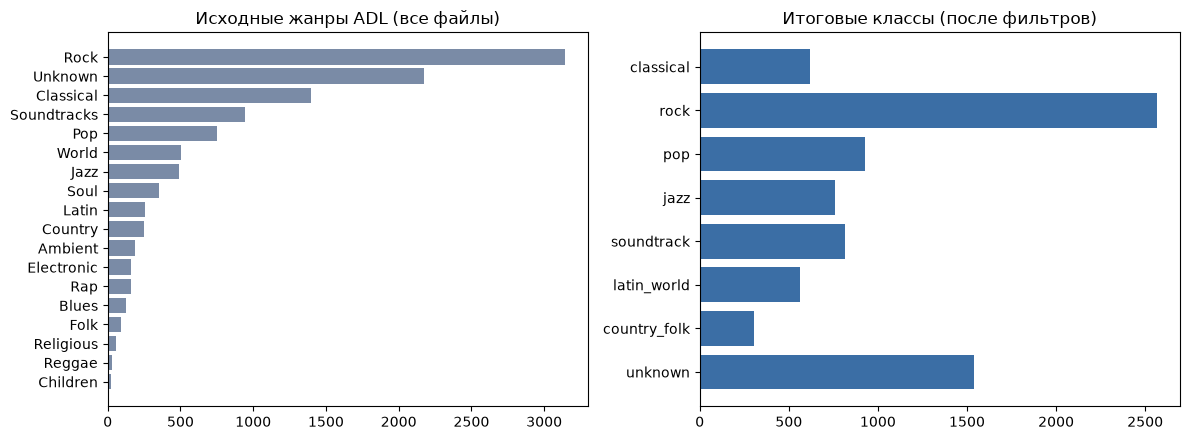

,пьес,исполнителей,исходные жанры
genre,,,
classical,617,171,Classical
rock,2567,1429,Rock
pop,930,576,"Pop, Rap, Electronic, Reggae, Children"
jazz,759,425,"Jazz, Blues, Soul"
soundtrack,814,343,"Soundtracks, Ambient"
latin_world,563,292,"World, Latin"
country_folk,302,175,"Country, Folk, Religious"
unknown,1539,1189,Unknown


In [8]:
import matplotlib.pyplot as plt
genres = vocab.genres

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
raw = df['genre_raw'].value_counts()
ax[0].barh(raw.index[::-1], raw.values[::-1], color='#7a8ba6'); ax[0].set_title('Исходные жанры ADL (все файлы)')
cls = kept['genre'].value_counts().reindex(genres)
ax[1].barh(cls.index[::-1], cls.values[::-1], color='#3b6ea5'); ax[1].set_title('Итоговые классы (после фильтров)')
plt.tight_layout(); plt.show()

table = kept.groupby('genre').agg(пьес=('path', 'size'), исполнителей=('artist', 'nunique')).reindex(genres)
table['исходные жанры'] = [', '.join(k for k, v in CONFIG['genre_map'].items() if v == g) for g in genres]
table

### Фильтрация и размеры такта

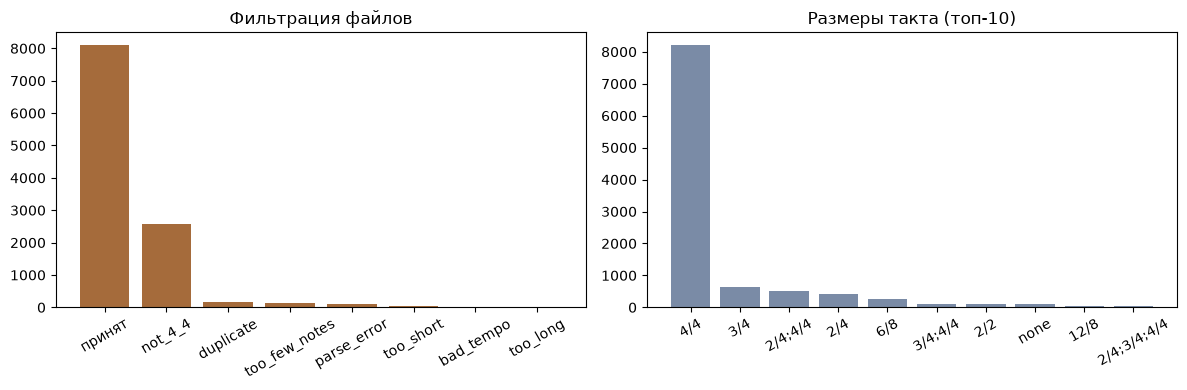

,файлов
reject,
принят,8091
not_4_4,2561
duplicate,151
too_few_notes,126
parse_error,89
too_short,39
bad_tempo,25
too_long,5


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
rej = df['reject'].replace('', 'принят').value_counts()
ax[0].bar(rej.index, rej.values, color='#a56b3b'); ax[0].set_title('Фильтрация файлов')
ts = df.loc[df['error'] == '', 'time_signatures'].value_counts().head(10)
ax[1].bar(ts.index, ts.values, color='#7a8ba6'); ax[1].set_title('Размеры такта (топ-10)')
for a in ax:
    a.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()
rej.to_frame('файлов')

### Длина, темп и плотность нот по жанрам

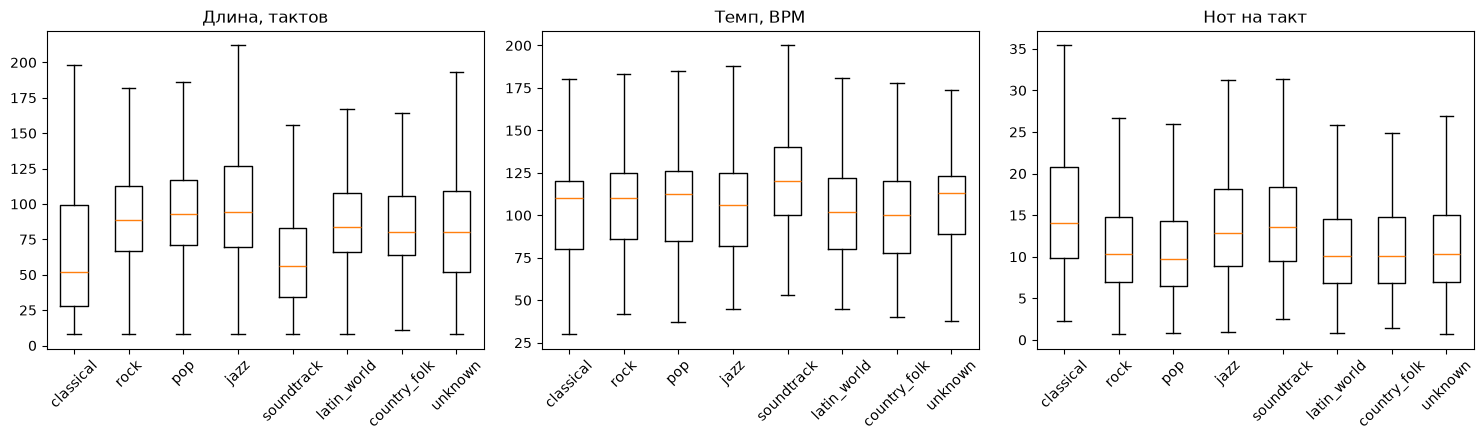

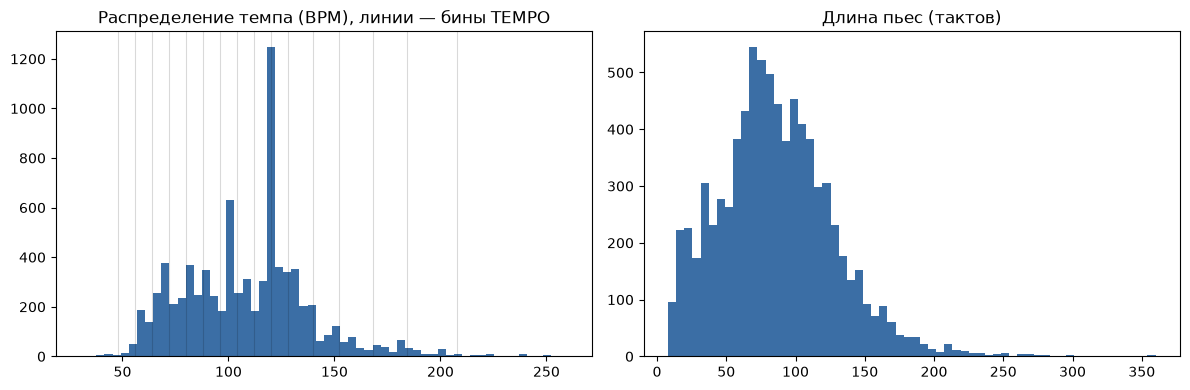

,n_bars,bpm,notes_per_bar,mean_pitch,n_tokens
genre,,,,,
classical,52.0,110.0,14.0,62.9,2692.0
rock,89.0,110.0,10.3,61.0,3151.0
pop,93.0,112.5,9.7,61.3,2984.0
jazz,94.0,106.0,12.8,62.8,4210.0
soundtrack,56.0,120.0,13.5,60.8,2568.5
latin_world,84.0,102.0,10.1,61.4,2947.0
country_folk,80.0,100.0,10.1,60.7,2992.0
unknown,80.0,113.0,10.4,61.6,2742.0


In [10]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
for a, col, title in zip(ax, ['n_bars', 'bpm', 'notes_per_bar'], ['Длина, тактов', 'Темп, BPM', 'Нот на такт']):
    a.boxplot([kept.loc[kept['genre'] == g, col] for g in genres], tick_labels=genres, showfliers=False)
    a.set_title(title); a.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(kept['bpm'], bins=60, color='#3b6ea5'); ax[0].set_title('Распределение темпа (BPM), линии — бины TEMPO')
for b in TEMPO_BINS:
    ax[0].axvline(b, color='k', alpha=0.15, lw=0.8)
ax[1].hist(kept['n_bars'], bins=60, color='#3b6ea5'); ax[1].set_title('Длина пьес (тактов)')
plt.tight_layout(); plt.show()

kept.groupby('genre')[['n_bars', 'bpm', 'notes_per_bar', 'mean_pitch', 'n_tokens']].median().reindex(genres).round(1)

### Тональности (оценка Крумхансла–Шмуклера)

Тональность пользователь не задаёт, модель выбирает её сама.

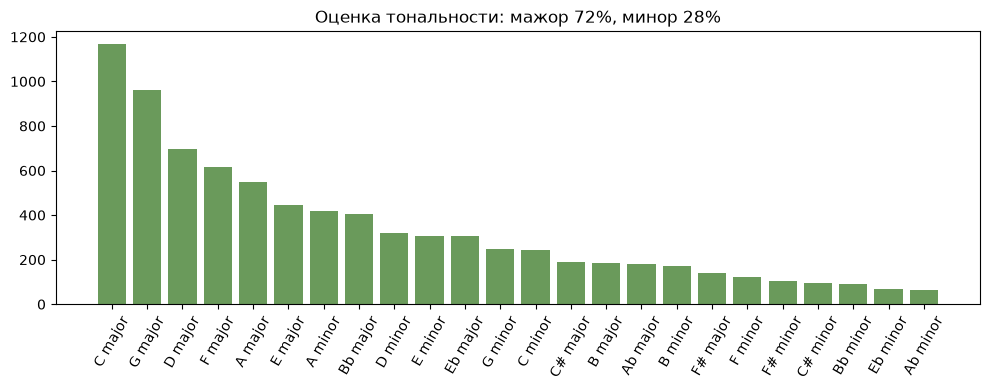

In [11]:
keys = kept['key_est'].dropna()
mode = keys.str.split().str[1].value_counts(normalize=True)
kc = keys.value_counts().head(24)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(kc.index, kc.values, color='#6a9a5b'); ax.tick_params(axis='x', rotation=60)
ax.set_title(f"Оценка тональности: мажор {mode.get('major', 0):.0%}, минор {mode.get('minor', 0):.0%}")
plt.tight_layout(); plt.show()

### Статистика токенов

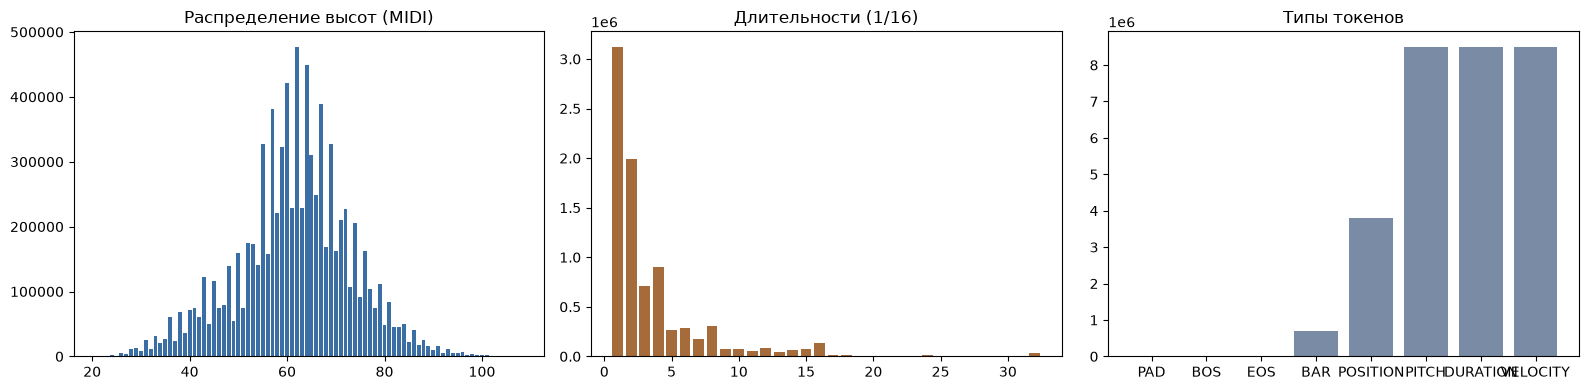

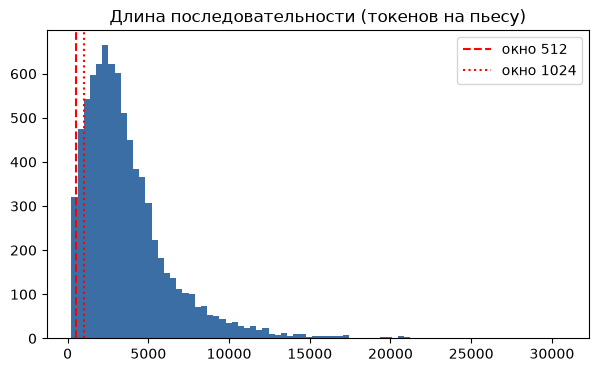

словарь: 190 токенов (тело 156, условия 34)
всего токенов: 30.0M, медиана на пьесу 3031, на такт ≈ 40
окно 512 ≈ 13 тактов, окно 1024 ≈ 26 тактов


In [12]:
kinds = {}
for t, c in enumerate(counts[: vocab.n_body]):
    kinds[vocab.kind(t)] = kinds.get(vocab.kind(t), 0) + int(c)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
a, b = vocab.ranges['PITCH']
ax[0].bar(range(21, 109), counts[a:b], color='#3b6ea5'); ax[0].set_title('Распределение высот (MIDI)')
a, b = vocab.ranges['DURATION']
ax[1].bar(range(1, 33), counts[a:b], color='#a56b3b'); ax[1].set_title('Длительности (1/16)')
ax[2].bar(list(kinds), list(kinds.values()), color='#7a8ba6'); ax[2].set_title('Типы токенов')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(kept['n_tokens'], bins=80, color='#3b6ea5'); ax.set_title('Длина последовательности (токенов на пьесу)')
ax.axvline(512, color='r', ls='--', label='окно 512'); ax.axvline(1024, color='r', ls=':', label='окно 1024')
ax.legend(); plt.show()

per_bar = (kept['n_tokens'] / kept['n_bars']).median()
print(f"словарь: {len(vocab)} токенов (тело {vocab.n_body}, условия {len(vocab) - vocab.n_body})")
print(f"всего токенов: {counts.sum() / 1e6:.1f}M, медиана на пьесу {kept['n_tokens'].median():.0f}, "
      f"на такт ≈ {per_bar:.0f}")
print(f"окно 512 ≈ {512 / per_bar:.0f} тактов, окно 1024 ≈ {1024 / per_bar:.0f} тактов")

## 7. MIDI → токены → MIDI

Берём пьесу, токенизируем, восстанавливаем и сравниваем ноты. Оба файла сохраняются на Диск
(`samples/week_1/`) — их можно скачать и сравнить на слух в любом MIDI-плеере (MuseScore, онлайн-плеер).

In [13]:
import zipfile
z = zipfile.ZipFile(zip_path)
row = kept[kept.genre == 'jazz'].sample(1, random_state=0).iloc[0]
data = z.read(row.path)
piece = read_midi(data)
tokens = tok.encode_piece(piece, row.genre)
print(row.artist, '—', row.title, f'| {piece.bpm} BPM, {piece.n_bars} тактов, {len(piece.notes)} нот, {len(tokens)} токенов')
print(' '.join(vocab.to_str(tokens[:40])))

notes, info = tok.decode(tokens)
print('совпадение нот:', quantized(notes) == quantized(piece.notes), '| условия из префикса:', info)
(SAMPLES / 'original.mid').write_bytes(data)
tok.decode_to_midi(tokens, SAMPLES / 'reconstructed.mid', bpm=piece.bpm)
print('сохранено в', SAMPLES)

Glenn Miller — Moonlight serenade | 84.0 BPM, 65 тактов, 627 нот, 2130 токенов
BOS GENRE_jazz TEMPO_88 LENGTH_64 BAR POSITION_0 PITCH_55 DURATION_15 VELOCITY_8 PITCH_58 DURATION_15 VELOCITY_8 PITCH_60 DURATION_15 VELOCITY_8 PITCH_63 DURATION_15 VELOCITY_8 POSITION_15 PITCH_51 DURATION_17 VELOCITY_8 PITCH_54 DURATION_17 VELOCITY_8 PITCH_57 DURATION_17 VELOCITY_8 PITCH_60 DURATION_17 VELOCITY_8 BAR BAR POSITION_0 PITCH_51 DURATION_7 VELOCITY_8 PITCH_56 DURATION_7 VELOCITY_8
совпадение нот: True | условия из префикса: {'genre': 'jazz', 'bpm': 88, 'n_bars': 64, 'n_bars_decoded': 65}
сохранено в ai-music-gen-work\samples\week_1


Round-trip на каждом 100-м файле датасета:

In [14]:
names = files['path'].tolist()[::100]
checked = 0
for name in names:
    try:
        piece = read_midi(z.read(name))
    except Exception:
        continue  # битые файлы бывают, их отсеивает фильтр
    notes, info = tok.decode(tok.encode_piece(piece, 'unknown'))
    assert quantized(notes) == quantized(piece.notes), name
    assert info['n_bars_decoded'] == piece.n_bars
    checked += 1
print(f'проверено файлов: {checked}, все совпадают нота в ноту')

проверено файлов: 111, все совпадают нота в ноту


## 8. Сохранение на Диск

- `data/pieces.csv` — по строке на файл (жанр, исполнитель, условия, статистика, причина отбраковки);
- `data/vocab.json`, `data/token_counts.npy`, `data/summary.json`;
- `code/*.py` — словарь, токенизатор и работа с датасетом (уже записаны выше).

In [15]:
df.to_csv(DATA / 'pieces.csv', index=False)
vocab.save(DATA / 'vocab.json')
np.save(DATA / 'token_counts.npy', counts)
(DATA / 'summary.json').write_text(json.dumps(summary, ensure_ascii=False, indent=1), encoding='utf-8')
for p in sorted(WORK.rglob('*')):
    if p.is_file() and '__pycache__' not in p.parts:
        print(f'{p.relative_to(WORK)}  ({p.stat().st_size / 1e6:.1f} МБ)')

code\adl.py  (0.0 МБ)
code\remi.py  (0.0 МБ)
code\vocab.py  (0.0 МБ)
data\adl-piano-midi.zip  (36.8 МБ)
data\pieces.csv  (3.2 МБ)
data\summary.json  (0.0 МБ)
data\token_counts.npy  (0.0 МБ)
data\vocab.json  (0.0 МБ)
samples\week_1\original.mid  (0.0 МБ)
samples\week_1\reconstructed.mid  (0.0 МБ)
